# TP — Classification multiclasses des caractères Tifinagh avec un MLP

**Base : AMHCD — Amazigh Handwritten Character Database**





## 1. Installation et imports



In [1]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
print("Imports OK")


Imports OK


## 2. Paramètres du dataset



In [3]:
import os
import zipfile
import pandas as pd

CANDIDATES = [
    os.getcwd(),
    r"c:\Users\lenovo\Downloads",
    r"c:\Users\lenovo\Documents",
    r"c:\Users\lenovo\Desktop",
    r"c:\Users\lenovo",
]

def find_dataset(roots):
    """Cherche un dossier 'tifinagh-images' OU un zip 'amhcd'."""
    for root in roots:
        if not os.path.isdir(root):
            continue
        for dirpath, dirnames, filenames in os.walk(root):
            for d in dirnames:
                if "tifinagh" in d.lower():
                    return ("dir", os.path.join(dirpath, d))
            for f in filenames:
                if "amhcd" in f.lower() and f.lower().endswith(".zip"):
                    return ("zip", os.path.join(dirpath, f))
            if dirpath.count(os.sep) - root.count(os.sep) > 4:
                dirnames.clear()
    return (None, None)

print("=== Recherche du dataset ===")
kind, found = find_dataset(CANDIDATES)
print("  Type   :", kind)
print("  Chemin :", found)

if kind is None:
    raise FileNotFoundError(
        " Aucun dataset trouvé.\n"
        "   → Télécharge 'amhcd-data-64.zip' sur Kaggle\n"
        "   → Place-le dans c:\\Users\\lenovo\\Downloads\\\n"
        "   → Relance cette cellule."
    )

if kind == "zip":
    extract_to = os.path.dirname(found)
    print(f"\nExtraction de {found} vers {extract_to} ...")
    with zipfile.ZipFile(found, "r") as z:
        z.extractall(extract_to)
    print("Extraction terminée.")

    kind2, DATA_DIR = find_dataset([extract_to])
    if kind2 != "dir":
        
        DATA_DIR = None
        for dirpath, dirnames, _ in os.walk(extract_to):
            if len(dirnames) > 5:
                DATA_DIR = dirpath
                break
        if DATA_DIR is None:
            raise FileNotFoundError(
                f"Zip extrait mais aucun dossier de classes trouvé sous {extract_to}"
            )
else:
    DATA_DIR = found

print("\nDATA_DIR final :", DATA_DIR)
print("Existe :", os.path.isdir(DATA_DIR))

csv_path = os.path.join(DATA_DIR, "labels-map.csv")
image_paths, labels = [], []

if os.path.isfile(csv_path):
    labels_df = pd.read_csv(csv_path)
    if not {"image_path", "label"}.issubset(labels_df.columns):
        raise ValueError("Le CSV doit contenir les colonnes image_path et label.")
    print("CSV chargé :", csv_path)
else:
    for label_dir in sorted(os.listdir(DATA_DIR)):
        label_path = os.path.join(DATA_DIR, label_dir)
        if os.path.isdir(label_path):
            for img_name in sorted(os.listdir(label_path)):
                img_path = os.path.join(label_path, img_name)
                if os.path.isfile(img_path):
                    image_paths.append(img_path)
                    labels.append(label_dir)

    labels_df = pd.DataFrame({
        "image_path": image_paths,
        "label": labels
    })

if labels_df.empty:
    raise ValueError(
        f"Aucune image trouvée dans {DATA_DIR}.\n"
        f"Contenu : {os.listdir(DATA_DIR)[:20]}"
    )

print(f"\n Nombre d'images : {len(labels_df)}")
print(f" Nombre de classes : {labels_df['label'].nunique()}")
display(labels_df.head())

=== Recherche du dataset ===
  Type   : dir
  Chemin : c:\Users\lenovo\Downloads\S2\Apprentissage profond\devoirs\Classification des Caractères Tifinagh

DATA_DIR final : c:\Users\lenovo\Downloads\S2\Apprentissage profond\devoirs\Classification des Caractères Tifinagh
Existe : True

 Nombre d'images : 10
 Nombre de classes : 4


,image_path,label
0,c:\Users\lenovo\Downloads\S2\Apprentissage pro...,Classification des Caractères Tifinagh
1,c:\Users\lenovo\Downloads\S2\Apprentissage pro...,Classification des Caractères Tifinagh
2,c:\Users\lenovo\Downloads\S2\Apprentissage pro...,Classification des Caractères Tifinagh
3,c:\Users\lenovo\Downloads\S2\Apprentissage pro...,Classification des Caractères Tifinagh
4,c:\Users\lenovo\Downloads\S2\Apprentissage pro...,Classification des Caractères Tifinagh


In [4]:
import os
import zipfile
import pandas as pd

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".pgm", ".ppm")
DATA_DIR_CANDIDAT = r"c:\Users\lenovo\Downloads\AMHCD_64"

def contient_classes(path):
    """Vérifie qu'un dossier contient au moins 5 sous-dossiers (= classes)."""
    if not os.path.isdir(path):
        return False
    n = sum(1 for d in os.listdir(path) if os.path.isdir(os.path.join(path, d)))
    return n >= 5

def trouver_racine_images(path):
    """Descend récursivement jusqu'au dossier qui contient les sous-dossiers de classes."""
    if contient_classes(path):
        return path
    for d in sorted(os.listdir(path)):
        full = os.path.join(path, d)
        if os.path.isdir(full) and contient_classes(full):
            return full
    return None

DATA_DIR = trouver_racine_images(DATA_DIR_CANDIDAT)

if DATA_DIR is None:
    raise FileNotFoundError(
        f"Aucun dossier de classes trouvé dans {DATA_DIR_CANDIDAT}.\n"
        f"Contenu : {os.listdir(DATA_DIR_CANDIDAT)}"
    )

print("DATA_DIR final :", DATA_DIR)
print("Existe :", os.path.isdir(DATA_DIR))

csv_path = os.path.join(DATA_DIR, "labels-map.csv")
image_paths, labels = [], []

if os.path.isfile(csv_path):
    labels_df = pd.read_csv(csv_path)
    if not {"image_path", "label"}.issubset(labels_df.columns):
        raise ValueError("Le CSV doit contenir image_path et label.")
    labels_df = labels_df[
        labels_df["image_path"].str.lower().str.endswith(IMG_EXTS)
    ].reset_index(drop=True)
    print("CSV chargé :", csv_path)
else:
    for label_dir in sorted(os.listdir(DATA_DIR)):
        label_path = os.path.join(DATA_DIR, label_dir)
        if not os.path.isdir(label_path):
            continue
        for img_name in sorted(os.listdir(label_path)):
            if not img_name.lower().endswith(IMG_EXTS):
                continue
            image_paths.append(os.path.join(label_path, img_name))
            labels.append(label_dir)

    labels_df = pd.DataFrame({"image_path": image_paths, "label": labels})

if labels_df.empty:
    raise ValueError(f"Aucune image valide dans {DATA_DIR}")

print(f"\n Nombre d'images : {len(labels_df)}")
print(f" Nombre de classes : {labels_df['label'].nunique()}")
print("\nRépartition (top 10) :")
print(labels_df["label"].value_counts().head(10))
display(labels_df.head())

DATA_DIR final : c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64
Existe : True

 Nombre d'images : 25740
 Nombre de classes : 33

Répartition (top 10) :
label
ya      780
yab     780
yach    780
yad     780
yadd    780
yae     780
yaf     780
yag     780
yagh    780
yagw    780
Name: count, dtype: int64


,image_path,label
0,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya
1,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya
2,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya
3,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya
4,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya


In [5]:
import os
import zipfile
import pandas as pd

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".pgm", ".ppm")

DATA_DIR_CANDIDAT = r"c:\Users\lenovo\Downloads\AMHCD_64"

def contient_classes(path, min_classes=5):
    if not os.path.isdir(path):
        return False
    n = sum(1 for d in os.listdir(path) if os.path.isdir(os.path.join(path, d)))
    return n >= min_classes

def trouver_racine_images(path):
    if contient_classes(path):
        return path
    for d in sorted(os.listdir(path)):
        full = os.path.join(path, d)
        if os.path.isdir(full) and contient_classes(full):
            return full
    return None

DATA_DIR = trouver_racine_images(DATA_DIR_CANDIDAT)

if DATA_DIR is None:
    raise FileNotFoundError(
        f"Aucun dossier de classes trouvé dans {DATA_DIR_CANDIDAT}.\n"
        f"Contenu : {os.listdir(DATA_DIR_CANDIDAT)}"
    )

print("DATA_DIR final :", DATA_DIR)
print("Existe :", os.path.isdir(DATA_DIR))

csv_path = os.path.join(DATA_DIR, "labels-map.csv")
image_paths, labels = [], []

if os.path.isfile(csv_path):
    labels_df = pd.read_csv(csv_path)
    if not {"image_path", "label"}.issubset(labels_df.columns):
        raise ValueError("Le CSV doit contenir image_path et label.")
    labels_df = labels_df[
        labels_df["image_path"].str.lower().str.endswith(IMG_EXTS)
    ].reset_index(drop=True)
    print("CSV chargé :", csv_path)
else:
    for label_dir in sorted(os.listdir(DATA_DIR)):
        label_path = os.path.join(DATA_DIR, label_dir)
        if not os.path.isdir(label_path):
            continue
        for img_name in sorted(os.listdir(label_path)):
            if not img_name.lower().endswith(IMG_EXTS):
                continue
            image_paths.append(os.path.join(label_path, img_name))
            labels.append(label_dir)

    labels_df = pd.DataFrame({"image_path": image_paths, "label": labels})

assert len(labels_df) > 20000, f" labels_df corrompu : {len(labels_df)} lignes (attendu ~25740)"
assert labels_df["label"].nunique() == 33, f" Nombre de classes : {labels_df['label'].nunique()} (attendu 33)"

print(f"\n Nombre d'images : {len(labels_df)}")
print(f" Nombre de classes : {labels_df['label'].nunique()}")
print("\nRépartition (top 10) :")
print(labels_df["label"].value_counts().head(10))
display(labels_df.head())

DATA_DIR final : c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64
Existe : True

 Nombre d'images : 25740
 Nombre de classes : 33

Répartition (top 10) :
label
ya      780
yab     780
yach    780
yad     780
yadd    780
yae     780
yaf     780
yag     780
yagh    780
yagw    780
Name: count, dtype: int64


,image_path,label
0,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya
1,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya
2,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya
3,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya
4,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya


## 3. Encodage des labels et prétraitement des images

Chaque image est :
1. convertie en niveaux de gris ;
2. redimensionnée de **64×64 à 32×32** ;
3. normalisée par 255 ;
4. aplatie en un vecteur de **1024 caractéristiques**.


In [6]:
label_encoder = LabelEncoder()
labels_df["label_encoded"] = label_encoder.fit_transform(labels_df["label"])
num_classes = len(label_encoder.classes_)

print("Nombre de classes :", num_classes)
print("Classes :", list(label_encoder.classes_))


Nombre de classes : 33
Classes : ['ya', 'yab', 'yach', 'yad', 'yadd', 'yae', 'yaf', 'yag', 'yagh', 'yagw', 'yah', 'yahh', 'yaj', 'yak', 'yakw', 'yal', 'yam', 'yan', 'yaq', 'yar', 'yarr', 'yas', 'yass', 'yat', 'yatt', 'yaw', 'yax', 'yay', 'yaz', 'yazz', 'yey', 'yi', 'yu']


In [7]:
import os
import pandas as pd

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".pgm", ".ppm")

DATA_DIR = r"c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64"

print("DATA_DIR :", DATA_DIR)
print("Existe   :", os.path.isdir(DATA_DIR))

csv_path = os.path.join(DATA_DIR, "labels-map.csv")
image_paths, labels = [], []

if os.path.isfile(csv_path):
    labels_df = pd.read_csv(csv_path)
    if not {"image_path", "label"}.issubset(labels_df.columns):
        raise ValueError("Le CSV doit contenir image_path et label.")
    labels_df = labels_df[
        labels_df["image_path"].str.lower().str.endswith(IMG_EXTS)
    ].reset_index(drop=True)
    print("CSV chargé :", csv_path)
else:
    for label_dir in sorted(os.listdir(DATA_DIR)):
        label_path = os.path.join(DATA_DIR, label_dir)
        if not os.path.isdir(label_path):
            continue
        for img_name in sorted(os.listdir(label_path)):
            if not img_name.lower().endswith(IMG_EXTS):
                continue
            image_paths.append(os.path.join(label_path, img_name))
            labels.append(label_dir)

    labels_df = pd.DataFrame({"image_path": image_paths, "label": labels})

assert len(labels_df) > 20000, f" labels_df corrompu : {len(labels_df)} lignes"
assert labels_df["label"].nunique() == 33, f" Classes : {labels_df['label'].nunique()}"

print(f"\n Nombre d'images : {len(labels_df)}")
print(f" Nombre de classes : {labels_df['label'].nunique()}")
print("\nRépartition (top 10) :")
print(labels_df["label"].value_counts().head(10))
display(labels_df.head())

DATA_DIR : c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64
Existe   : True

 Nombre d'images : 25740
 Nombre de classes : 33

Répartition (top 10) :
label
ya      780
yab     780
yach    780
yad     780
yadd    780
yae     780
yaf     780
yag     780
yagh    780
yagw    780
Name: count, dtype: int64


,image_path,label
0,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya
1,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya
2,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya
3,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya
4,c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya...,ya


## 4. Séparation Train / Validation / Test

Le sujet utilise :
- 20 % pour le test ;
- puis 25 % de la partie restante pour la validation.

On obtient donc environ **60 % train, 20 % validation, 20 % test**.


In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
labels_df["label_encoded"] = label_encoder.fit_transform(labels_df["label"])
num_classes = len(label_encoder.classes_)

print("Nombre de classes :", num_classes)
print("Classes :", list(label_encoder.classes_))
print("label_encoded créé.")

Nombre de classes : 33
Classes : ['ya', 'yab', 'yach', 'yad', 'yadd', 'yae', 'yaf', 'yag', 'yagh', 'yagw', 'yah', 'yahh', 'yaj', 'yak', 'yakw', 'yal', 'yam', 'yan', 'yaq', 'yar', 'yarr', 'yas', 'yass', 'yat', 'yatt', 'yaw', 'yax', 'yay', 'yaz', 'yazz', 'yey', 'yi', 'yu']
label_encoded créé.


In [9]:
import os
import cv2

print("Nombre de lignes dans labels_df :", len(labels_df))
print()
print("=== 10 premiers chemins ===")
for p in labels_df["image_path"].head(10):
    exists = os.path.isfile(p)
    ext = os.path.splitext(p)[1].lower()
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE) if exists else None
    print(f"existe={exists} | ext={ext} | imread={'OK' if img is not None else 'None'} | {p}")

print()
print("=== Extensions présentes dans labels_df ===")
exts = labels_df["image_path"].str.lower().str.rsplit(".", n=1).str[-1].value_counts()
print(exts)

print()
print("=== labels (classes) ===")
print(labels_df["label"].value_counts().head(10))

Nombre de lignes dans labels_df : 25740

=== 10 premiers chemins ===
existe=True | ext=.jpeg | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_1.jpeg
existe=True | ext=.jpeg | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_10.jpeg
existe=True | ext=.jpeg | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_100.jpeg
existe=True | ext=.jpeg | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_101.jpeg
existe=True | ext=.jpeg | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_102.jpeg
existe=True | ext=.jpeg | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_103.jpeg
existe=True | ext=.jpeg | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_104.jpeg
existe=True | ext=.jpeg | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_105.jpeg
existe=True | ext=.jpeg | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_106.jpeg
existe=True | ext=.jpeg | imread=OK | c:\Users\lenovo\Downloa

## 5. One-hot encoding des labels

In [10]:
import os
import cv2
import numpy as np

print("labels_df lignes :", len(labels_df))
print()

print("Extensions dans labels_df :")
exts = labels_df["image_path"].str.lower().str.rsplit(".", n=1).str[-1].value_counts()
print(exts)
print()

print("=== Test des 10 premiers ===")
for p in labels_df["image_path"].head(10):
    exists = os.path.isfile(p)
    img = None
    if exists:
        buf = np.fromfile(p, dtype=np.uint8)
        img = cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)
    print(f"existe={exists} | imread={'OK' if img is not None else 'None'} | {p}")

labels_df lignes : 25740

Extensions dans labels_df :
image_path
jpeg    25740
Name: count, dtype: int64

=== Test des 10 premiers ===
existe=True | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_1.jpeg
existe=True | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_10.jpeg
existe=True | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_100.jpeg
existe=True | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_101.jpeg
existe=True | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_102.jpeg
existe=True | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_103.jpeg
existe=True | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_104.jpeg
existe=True | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_105.jpeg
existe=True | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_106.jpeg
existe=True | imread=OK | c:\Users\lenovo\Downloads\AMHCD_64\AMHCD_64\ya\ya_107.jpeg


In [11]:
import numpy as np
import cv2

def load_and_preprocess_image(image_path, target_size=(32, 32)):
    try:
        buf = np.fromfile(image_path, dtype=np.uint8)  
        img = cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)
    except Exception:
        return None
    if img is None:
        return None
    img = cv2.resize(img, target_size)
    img = img.astype(np.float32) / 255.0
    return img.flatten()

X_list, y_list = [], []
ignored = 0
for p, lab in zip(labels_df["image_path"], labels_df["label_encoded"]):
    feat = load_and_preprocess_image(p)
    if feat is None:
        ignored += 1
    else:
        X_list.append(feat)
        y_list.append(lab)

print("Images chargées :", len(X_list))
print("Images ignorées :", ignored)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int64)

print("X shape :", X.shape)
print("y shape :", y.shape)

if len(X) == 0:
    raise RuntimeError(
        " Aucune image chargée. Vérifie que DATA_DIR pointe bien sur un dossier "
        "contenant des sous-dossiers de classes avec des fichiers .png/.jpg/.bmp/.tif"
    )

assert X.shape[1] == 32 * 32
print(" X et y prêts.")

Images chargées : 25740
Images ignorées : 0
X shape : (25740, 1024)
y shape : (25740,)
 X et y prêts.


In [12]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print("Train :", X_train.shape, y_train.shape)
print("Validation :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train : (15444, 1024) (15444,)
Validation : (5148, 1024) (5148,)
Test : (5148, 1024) (5148,)


In [13]:
from sklearn.preprocessing import OneHotEncoder

try:
    one_hot_encoder = OneHotEncoder(sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(sparse=False)

y_train_one_hot = one_hot_encoder.fit_transform(y_train.reshape(-1, 1))
y_val_one_hot   = one_hot_encoder.transform(y_val.reshape(-1, 1))
y_test_one_hot  = one_hot_encoder.transform(y_test.reshape(-1, 1))

print("y_train_one_hot :", y_train_one_hot.shape)
print("y_val_one_hot   :", y_val_one_hot.shape)
print("y_test_one_hot  :", y_test_one_hot.shape)

y_train_one_hot : (15444, 33)
y_val_one_hot   : (5148, 33)
y_test_one_hot  : (5148, 33)


## 6. Fonctions d'activation

### ReLU
\[
ReLU(z)=\max(0,z)
\]

### Dérivée de ReLU
\[
ReLU'(z)=
\begin{cases}
1 & z>0\\
0 & z\leq0
\end{cases}
\]

### Softmax
\[
\hat y_c=\frac{e^{z_c}}{\sum_{j=1}^{33}e^{z_j}}
\]


In [15]:
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


## 7. MLP multiclasses

Architecture :

\[
1024 \rightarrow 64 \rightarrow 32 \rightarrow 33
\]

Les deux couches cachées utilisent ReLU et la couche de sortie utilise Softmax.


In [16]:
class MultiClassNeuralNetwork:
    def __init__(self, layer_sizes, learning_rate=0.01):
        if not isinstance(layer_sizes, list) or len(layer_sizes) < 2:
            raise ValueError("layer_sizes doit être une liste d'au moins 2 éléments.")
        if not all(isinstance(s, int) and s > 0 for s in layer_sizes):
            raise ValueError("Toutes les tailles doivent être des entiers positifs.")
        if learning_rate <= 0:
            raise ValueError("Le learning rate doit être positif.")

        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.weights = []
        self.biases = []

        np.random.seed(42)

        for i in range(len(layer_sizes) - 1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * 0.01
            b = np.zeros((1, layer_sizes[i + 1]))
            self.weights.append(w)
            self.biases.append(b)

    def forward(self, X):
        self.activations = [X]
        self.z_values = []

        for i in range(len(self.weights) - 1):
            z = self.activations[-1] @ self.weights[i] + self.biases[i]
            self.z_values.append(z)
            self.activations.append(relu(z))

        z = self.activations[-1] @ self.weights[-1] + self.biases[-1]
        self.z_values.append(z)

        output = softmax(z)
        self.activations.append(output)

        return output

    def compute_loss(self, y_true, y_pred):
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    def compute_accuracy(self, y_true, y_pred):
        predictions = np.argmax(y_pred, axis=1)
        true_labels = np.argmax(y_true, axis=1)
        return np.mean(predictions == true_labels)

    def backward(self, X, y, outputs):
        m = X.shape[0]

        self.d_weights = [np.zeros_like(w) for w in self.weights]
        self.d_biases = [np.zeros_like(b) for b in self.biases]

        dZ = outputs - y

        self.d_weights[-1] = (self.activations[-2].T @ dZ) / m
        self.d_biases[-1] = np.sum(dZ, axis=0, keepdims=True) / m

        for i in range(len(self.weights) - 2, -1, -1):
            dZ = (dZ @ self.weights[i + 1].T) * relu_derivative(self.z_values[i])

            self.d_weights[i] = (self.activations[i].T @ dZ) / m
            self.d_biases[i] = np.sum(dZ, axis=0, keepdims=True) / m

        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * self.d_weights[i]
            self.biases[i] -= self.learning_rate * self.d_biases[i]

    def train(self, X, y, X_val, y_val, epochs=100, batch_size=32):
        train_losses, val_losses = [], []
        train_accuracies, val_accuracies = [], []

        for epoch in range(epochs):
            indices = np.random.permutation(X.shape[0])
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0.0
            n_batches = 0

            for i in range(0, X.shape[0], batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]

                outputs = self.forward(X_batch)
                epoch_loss += self.compute_loss(y_batch, outputs)
                self.backward(X_batch, y_batch, outputs)
                n_batches += 1

            train_loss = epoch_loss / n_batches

            train_pred = self.forward(X)
            train_accuracy = self.compute_accuracy(y, train_pred)

            val_pred = self.forward(X_val)
            val_loss = self.compute_loss(y_val, val_pred)
            val_accuracy = self.compute_accuracy(y_val, val_pred)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accuracies.append(train_accuracy)
            val_accuracies.append(val_accuracy)

            if epoch == 0 or (epoch + 1) % 10 == 0:
                print(
                    f"Epoch {epoch + 1:3d}/{epochs} | "
                    f"Train Loss: {train_loss:.4f} | "
                    f"Val Loss: {val_loss:.4f} | "
                    f"Train Acc: {train_accuracy:.4f} | "
                    f"Val Acc: {val_accuracy:.4f}"
                )

        return train_losses, val_losses, train_accuracies, val_accuracies

    def predict(self, X):
        outputs = self.forward(X)
        return np.argmax(outputs, axis=1)


## 8. Entraînement

Configuration du TP :
- learning rate = 0.01
- 100 epochs
- batch size = 32
- architecture 1024 → 64 → 32 → 33


In [17]:
layer_sizes = [X_train.shape[1], 64, 32, num_classes]

nn = MultiClassNeuralNetwork(
    layer_sizes,
    learning_rate=0.01
)

train_losses, val_losses, train_accuracies, val_accuracies = nn.train(
    X_train,
    y_train_one_hot,
    X_val,
    y_val_one_hot,
    epochs=100,
    batch_size=32
)


Epoch   1/100 | Train Loss: 3.4966 | Val Loss: 3.4965 | Train Acc: 0.0304 | Val Acc: 0.0305
Epoch  10/100 | Train Loss: 3.4965 | Val Loss: 3.4963 | Train Acc: 0.0668 | Val Acc: 0.0674
Epoch  20/100 | Train Loss: 3.4944 | Val Loss: 3.4938 | Train Acc: 0.0501 | Val Acc: 0.0513
Epoch  30/100 | Train Loss: 2.8464 | Val Loss: 2.9044 | Train Acc: 0.0787 | Val Acc: 0.0756
Epoch  40/100 | Train Loss: 2.1520 | Val Loss: 2.1801 | Train Acc: 0.2448 | Val Acc: 0.2519
Epoch  50/100 | Train Loss: 1.5240 | Val Loss: 2.6289 | Train Acc: 0.2638 | Val Acc: 0.2659
Epoch  60/100 | Train Loss: 1.0051 | Val Loss: 0.9456 | Train Acc: 0.7064 | Val Acc: 0.7005
Epoch  70/100 | Train Loss: 0.6914 | Val Loss: 0.8012 | Train Acc: 0.7683 | Val Acc: 0.7584
Epoch  80/100 | Train Loss: 0.5677 | Val Loss: 0.6000 | Train Acc: 0.8420 | Val Acc: 0.8296
Epoch  90/100 | Train Loss: 0.4702 | Val Loss: 0.6553 | Train Acc: 0.8342 | Val Acc: 0.8159
Epoch 100/100 | Train Loss: 0.4015 | Val Loss: 0.5602 | Train Acc: 0.8599 | Val 

## 9. Courbes d'apprentissage

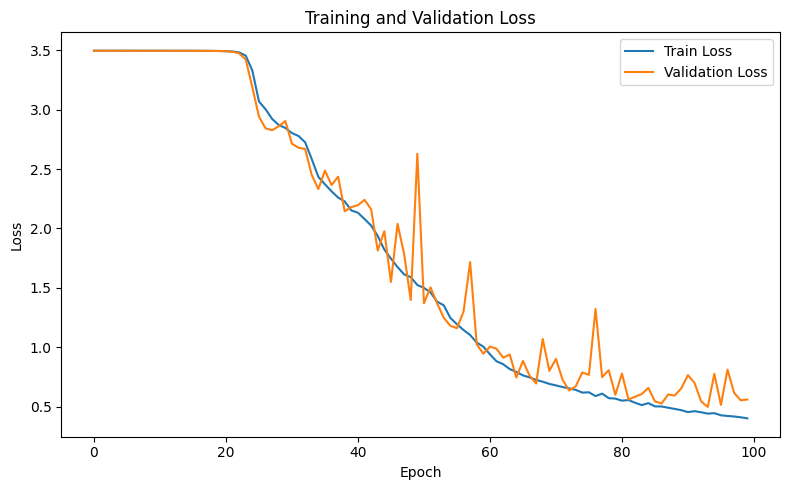

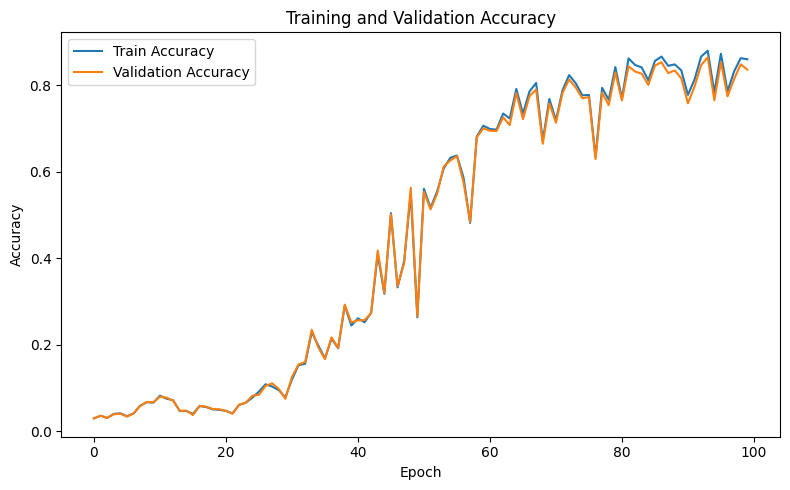

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_curve.png", dpi=200)
plt.show()


## 10. Évaluation sur le test

In [19]:
y_pred = nn.predict(X_test)

test_accuracy = np.mean(y_pred == y_test)

print(f"Test accuracy: {test_accuracy:.4f}")
print()
print("Classification report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


Test accuracy: 0.8364

Classification report:
              precision    recall  f1-score   support

          ya       0.97      0.99      0.98       156
         yab       0.91      0.97      0.94       156
        yach       0.93      0.89      0.91       156
         yad       0.97      0.90      0.93       156
        yadd       0.75      0.82      0.79       156
         yae       0.83      0.94      0.88       156
         yaf       0.97      0.92      0.94       156
         yag       0.89      0.82      0.85       156
        yagh       0.85      0.97      0.91       156
        yagw       0.99      0.62      0.76       156
         yah       0.92      0.79      0.85       156
        yahh       0.81      0.87      0.84       156
         yaj       0.95      0.84      0.89       156
         yak       0.83      0.82      0.83       156
        yakw       0.83      0.91      0.87       156
         yal       0.86      0.96      0.91       156
         yam       0.89      0.86  

## 11. Matrice de confusion

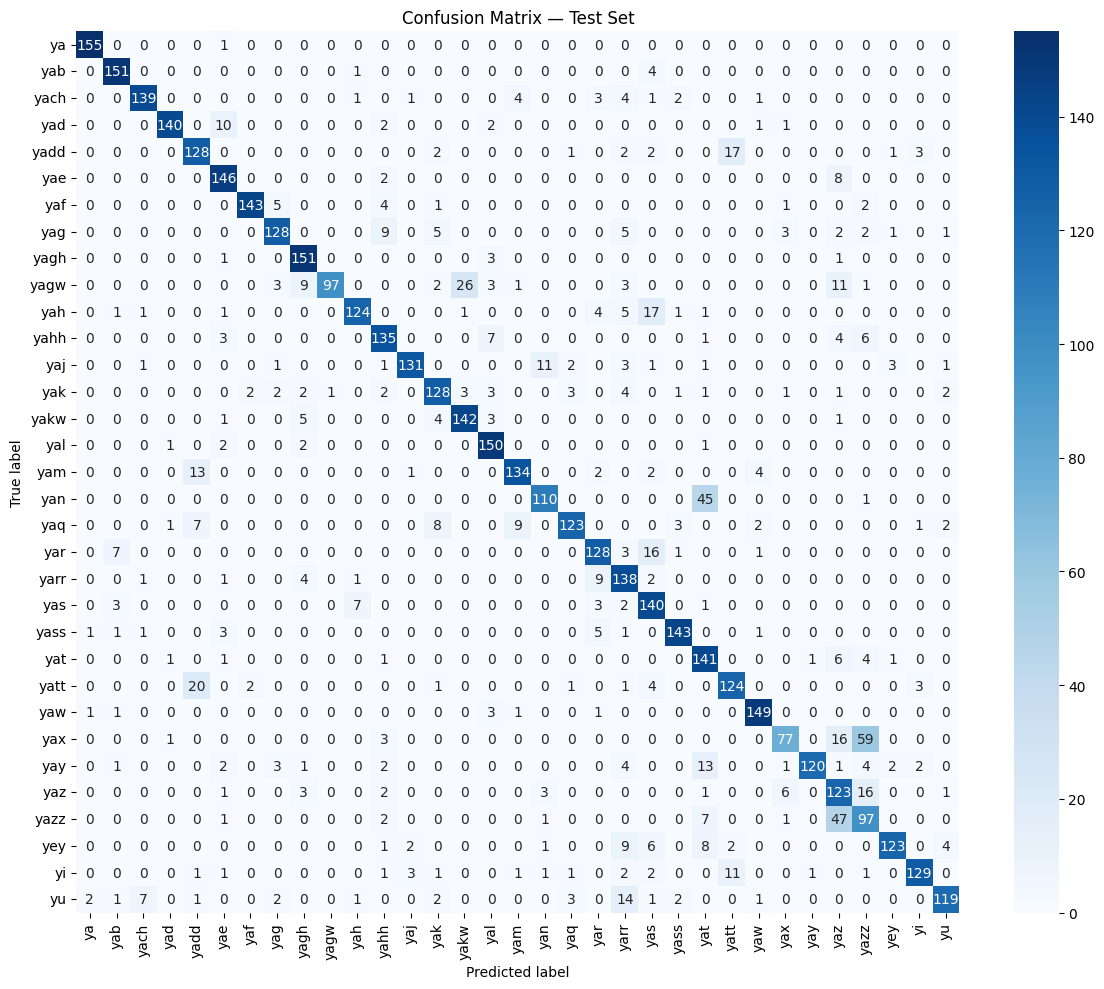

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix — Test Set")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()


## 12. Exemple de prédictions

Cette cellule affiche quelques images du test et leur classe réelle/prédite.

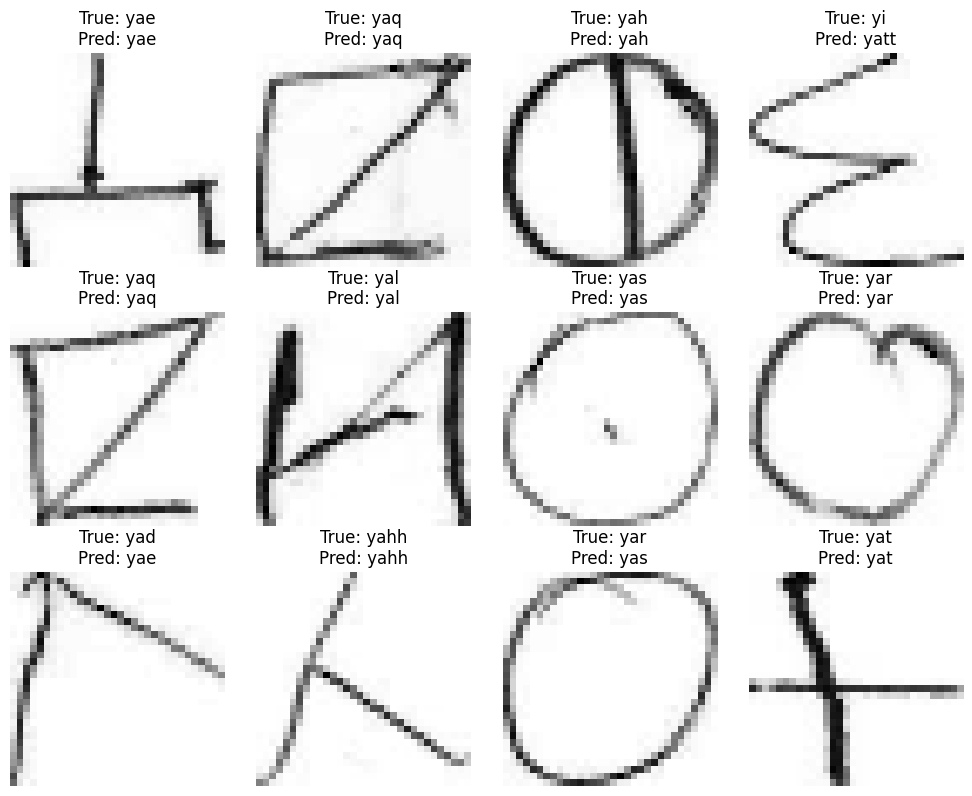

In [21]:
n_show = min(12, len(X_test))
indices = np.random.choice(len(X_test), n_show, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.ravel()

for ax, idx in zip(axes, indices):
    img = X_test[idx].reshape(32, 32)
    true_label = label_encoder.inverse_transform([y_test[idx]])[0]
    pred_label = label_encoder.inverse_transform([y_pred[idx]])[0]

    ax.imshow(img, cmap="gray")
    ax.set_title(f"True: {true_label}\nPred: {pred_label}")
    ax.axis("off")

for ax in axes[n_show:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=200)
plt.show()
